# UHPC Compressive Strength — Part 1: Exploratory Data Analysis

**Author:** K Flowers  
**Date:** January 2026

This project examines 810 Ultra-High-Performance Concrete (UHPC) mix designs to develop a model that predicts compressive strength. This notebook performs exploratory data analysis (EDA) by validating data quality, examining variable distributions, and analyzing relationships between mix components and compressive strength. The goal is to establish a clear understanding of the dataset characteristics before model development.

*Note: A 150 MPa compressive strength threshold is used as a benchmark for UHPC classification.*

**Pipeline Position:** Notebook 1 of 3 — Exploratory Analysis
- 01_exploratory_analysis.ipynb ← this notebook
- 02_model_development.ipynb
- 03_model_interpretation.ipynb

**Objective:** Evaluate data quality, examine feature-target relationships, and identify multicollinearity to guide model selection.

**Technical Approach:**
- Validate data quality by checking for missing values, duplicates, and out-of-range values to ensure reliable inputs for modeling
- Examine target and feature distributions to assess normality and identify transformation candidates
- Measure feature-target correlations to identify the strongest predictors of compressive strength
- Evaluate multicollinearity to determine whether regularization or tree-based models are needed

**Inputs:**
- `data/raw/uhpc_dataset.csv` — 810 UHPC mix designs with 13 features

**Outputs:**
- `data/processed/uhpc_dataset_cleaned.csv` — Cleaned dataset (792 records)
- `images/` — Visualizations for analysis and reporting

**Table of Contents**
1. Configure Environment
2. Load Data
3. Validate Data Quality
4. Analyze Target Variable
5. Analyze Feature Variables
6. Assess Multicollinearity
7. Conclusion
- Appendix A: Data Validation Ranges
- Appendix B: References

---
## 1. Configure Environment

### 1.1 Import Libraries

In [1]:
# Standard library
from pathlib import Path
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Libraries imported successfully")


Libraries imported successfully


### 1.2 Set Display and Plot Options

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Warnings
warnings.filterwarnings('ignore')

print("Display settings configured")

Display settings configured


### 1.3 Set Paths and Constants

In [ ]:
# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = PROJECT_ROOT / "images"

# Create directories if needed
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Input/output files
INPUT_FILE = DATA_DIR / "raw" / "uhpc_dataset.csv"

# Constants
RANDOM_STATE = 42

print("Paths and constants set")

---
## 2. Load Data

### 2.1 Load Dataset

In [ ]:
# Load the UHPC dataset from CSV file
df = pd.read_csv(INPUT_FILE)

print(f"Dataset loaded: {INPUT_FILE.name}")
print(f"  Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

### 2.2 Rename Columns and Review Data

In [5]:
# Rename columns from abbreviations to descriptive names
column_mapping = {
    'C': 'cement',
    'W': 'water',
    'FA': 'fly_ash',
    'SF': 'silica_fume',
    'NS': 'nano_silica',
    'QP': 'quartz_powder',
    'LP': 'limestone_powder',
    'A': 'aggregate',
    'S': 'slag',
    'SP': 'superplasticizer',
    'Fi': 'fiber',
    'T': 'temperature',
    'Age': 'age',
    'CS': 'compressive_strength'
}

df = df.rename(columns=column_mapping)

print("Columns renamed:")
print(df.columns.tolist())

Columns renamed:
['cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder', 'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber', 'superplasticizer', 'temperature', 'age', 'compressive_strength']


In [6]:
#  Define target variable, features, and analysis constants
TARGET = 'compressive_strength'

FEATURES = [
    'cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder',
    'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber',
    'superplasticizer', 'temperature', 'age'
]

UHPC_THRESHOLD = 150  # MPa minimum for UHPC (FHWA-HRT-18-036)

print(f"Target variable: {TARGET}")
print(f"Features: {len(FEATURES)} variables")
print(f"UHPC threshold: {UHPC_THRESHOLD} MPa")

Target variable: compressive_strength
Features: 13 variables
UHPC threshold: 150 MPa


**Units of Measurement**

**kg/m³:** cement, slag, silica_fume, limestone_powder, quartz_powder, fly_ash, nano_silica, aggregate, water, fiber, superplasticizer   

**°C:** temperature   

**days:** age

**MPa:** compressive_strength (TARGET)

---
## 3. Validate Data Quality

**Methodology:** Data quality is validated using a flag-and-filter approach:
- Flag rows with negative values, out-of-range values, and duplicate records
- Exclude flagged rows from the final dataset
- Preserve the original dataset to maintain transparency and reproducibility
- See Appendix A for defined acceptable value ranges

### 3.1 Check for Missing Values

In [7]:
# Check for missing values in each column
missing = df.isnull().sum()
max_len = max(len(col) for col in df.columns)

print("Missing Values Check:")
for col in df.columns:
    print(f"  {col:<{max_len}}: {missing[col]}")

print(f"\n  Total missing values:  {missing.sum()}")
print(f"  Columns with missing:  {(missing > 0).sum()}")

Missing Values Check:
  cement              : 0
  slag                : 0
  silica_fume         : 0
  limestone_powder    : 0
  quartz_powder       : 0
  fly_ash             : 0
  nano_silica         : 0
  aggregate           : 0
  water               : 0
  fiber               : 0
  superplasticizer    : 0
  temperature         : 0
  age                 : 0
  compressive_strength: 0

  Total missing values:  0
  Columns with missing:  0


### 3.2 Check for Invalid Values

Flag rows with negative values or values outside validation ranges.

*See Appendix A for detailed validation ranges and literature sources.*

In [8]:
# Set has_negative flag if rows have negative values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df['has_negatives'] = (df[numeric_cols] < 0).any(axis=1)

# count rows with and without negative values
total_rows = len(df)
rows_with_negatives = df['has_negatives'].sum()
rows_without_negatives = total_rows - rows_with_negatives

print("Negative Value Check:")
print(f"  Total rows:                      {total_rows}")
print(f"  Rows with negatives (flagged):   {rows_with_negatives}")
print(f"  Rows without negatives:          {rows_without_negatives}")


Negative Value Check:
  Total rows:                      810
  Rows with negatives (flagged):   0
  Rows without negatives:          810


In [9]:
# Define validation ranges for each variable, use min, max tuples
VALIDATION_RANGES = {
    'cement':              (200, 1500),
    'slag':                (0, 600),
    'silica_fume':         (0, 500),
    'limestone_powder':    (0, 1200),
    'quartz_powder':       (0, 500),
    'fly_ash':             (0, 400),
    'nano_silica':         (0, 100),
    'aggregate':           (0, 2500),
    'water':               (50, 350),
    'fiber':               (0, 300),
    'superplasticizer':    (0, 100),
    'temperature':         (0, 250),
    'age':                 (1, 1000),
    'compressive_strength': (0, 350)
}

print("Validation Ranges:")
print(f"  {len(VALIDATION_RANGES)} ranges defined")

Validation Ranges:
  14 ranges defined


In [10]:
# Validate values against ranges (vectorized - same pattern as negatives check)
cols = [c for c in VALIDATION_RANGES.keys() if c in df.columns]
mins = pd.Series({c: VALIDATION_RANGES[c][0] for c in cols})
maxs = pd.Series({c: VALIDATION_RANGES[c][1] for c in cols})

df['has_out_of_range'] = ((df[cols] < mins) | (df[cols] > maxs)).any(axis=1)

total_rows = len(df)
rows_out_of_range = df['has_out_of_range'].sum()
rows_in_range = total_rows - rows_out_of_range

print("Range Validation Check:")
print(f"  Total rows:                     {total_rows}")
print(f"  Rows out of range (flagged):    {rows_out_of_range}")
print(f"  Rows within valid range:        {rows_in_range}")

Range Validation Check:
  Total rows:                     810
  Rows out of range (flagged):    0
  Rows within valid range:        810


### 3.3 Check for Duplicates

In [11]:
# Check for duplicate rows and flag 
original_cols = [col for col in df.columns if col not in ['has_negatives', 'has_out_of_range', 'has_duplicate']]
df['has_duplicate'] = df.duplicated(subset=original_cols, keep='first')
duplicate_count = df['has_duplicate'].sum()

print("Duplicate Row Check:")
print(f"  Duplicate rows (flagged): {duplicate_count} ({duplicate_count/len(df)*100:.2f}%)")

Duplicate Row Check:
  Duplicate rows (flagged): 18 (2.22%)


**Note:**  The dataset documentation does not indicate whether duplicates represent repeated experiments or data entry errors. Duplicate rows (2.2%) will be removed to avoid impacting model performance.

### 3.4 Review Summary Statistics

Check for zero-inflation, unusual min/max values, and feature variability to validate data quality and guide modeling.

In [12]:
# Display summary statistics for all numeric columns including non-zero counts
print("Summary Statistics:")

# Get standard describe statistics
stats_df = df.describe().T

# Add a column to count the number of non-zero records
stats_df['non_zero_records'] = (df > 0).sum()

# Rename count to total_records for clarity
stats_df = stats_df.rename(columns={'count': 'total_records'})

# Reorder columns to inlcude the count of non_zero_records after total_records
cols = ['total_records', 'non_zero_records', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
stats_df = stats_df[cols]

stats_df

Summary Statistics:


,total_records,non_zero_records,mean,std,min,25%,50%,75%,max
cement,810.00,810,737.91,173.46,270.00,620.20,770.50,850.00,1251.20
slag,810.00,98,25.19,74.37,0.00,0.00,0.00,0.00,375.00
silica_fume,810.00,639,136.99,104.14,0.00,43.70,144.00,219.00,433.70
limestone_powder,810.00,114,41.93,133.13,0.00,0.00,0.00,0.00,1058.20
quartz_powder,810.00,132,33.27,79.67,0.00,0.00,0.00,0.00,397.00
fly_ash,810.00,117,26.26,67.46,0.00,0.00,0.00,0.00,356.00
nano_silica,810.00,211,3.64,7.78,0.00,0.00,0.00,4.00,47.50
aggregate,810.00,810,1150.11,312.15,407.80,873.00,1116.00,1301.40,1992.00
water,810.00,810,179.89,25.57,90.00,163.00,177.00,192.50,272.60
fiber,810.00,329,56.04,75.23,0.00,0.00,0.00,156.00,234.00


**Modeling Note:** 
- Wide variation in feature quantities (0–2000 kg/m³) indicate scaling may be required during modeling.
- High skew among several features (possibly due to zero inflation) may require consideration during modeling
- Initial review of tarrget variable (compresive strenth) suggests normal distribution with no abnormal outliers

### 3.5 Export Cleaned Dataset (`uhpc_dataset_cleaned.csv`)

Filter rows with negative, out-of-range, or duplicate data and save cleaned dataset for modeling.

In [ ]:
# Filter out rows with neg, out-of-range, or duplicate data 
rows_before = len(df)

# Remove rows with negatives, out-of-range values, or duplicates
df = df[~(df['has_negatives'] | df['has_out_of_range'] | df['has_duplicate'])].copy()

# Drop helper columns
df = df.drop(columns=['has_negatives', 'has_out_of_range', 'has_duplicate'])

rows_after = len(df)
rows_removed = rows_before - rows_after

print("Data Filtering Summary:")
print(f"  Rows before: {rows_before}")
print(f"  Rows removed: {rows_removed}")
print(f"  Rows after: {rows_after}")
print(f"  Retention rate: {rows_after/rows_before*100:.1f}%")

# Save cleaned dataset for modeling
OUTPUT_FILE = DATA_DIR / "processed" / "uhpc_dataset_cleaned.csv"
df.to_csv(OUTPUT_FILE, index=False)
print(f"\nCleaned dataset saved: {OUTPUT_FILE.name}")

**Section 3 Summary:**
- No missing, negative, or out-of-range values were identified
- 18 duplicate rows (2.2%) were flagged and removed
- The cleaned dataset contains 792 records (97.8% retention)
- No structural data issues were detected; zero-inflation in some features may influence model selection.


---
## 4. Analyze Target Variable

**Methodology:** The target distribution is analyzed to understand shape, normality, and implications for model selection:
- Visualize distribution shape using histogram with KDE
- Test normality using Q–Q plot and D'Agostino–Pearson test
- Calculate skewness and kurtosis 
- Evaluate sample distribution relative to the UHPC threshold (150 MPa)

### 4.1 Distribution (Histogram + KDE)

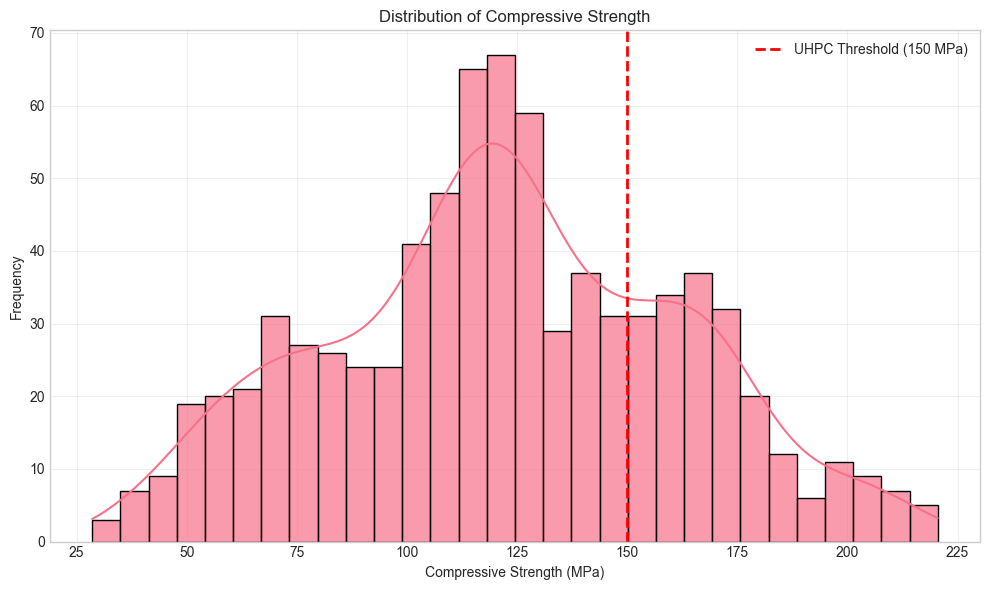

In [14]:
# Plot histogram with kernel density estimate for target variable
plt.figure(figsize=(10, 6))
sns.histplot(df[TARGET], kde=True, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=UHPC_THRESHOLD, color='red', linestyle='--', linewidth=2, 
            label=f'UHPC Threshold ({UHPC_THRESHOLD} MPa)')
plt.title(f'Distribution of Compressive Strength', fontsize=12)
plt.xlabel('Compressive Strength (MPa)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The distribution appears approximately symmetric and centered around 120 MPa, which suggests the target may not need transformation for modeling.

In [15]:
# Display descriptive statistics for target variable
print(f"Target Variable: {TARGET}\n")
print(df[TARGET].describe().round(2))
print(f"\nIQR: {df[TARGET].quantile(0.75) - df[TARGET].quantile(0.25):.2f} MPa")

Target Variable: compressive_strength

count   792.00
mean    122.09
std      40.01
min      28.51
25%      94.60
50%     120.90
75%     151.00
max     220.50
Name: compressive_strength, dtype: float64

IQR: 56.40 MPa


**Interpretation:** The dataset covers a wide performance range (29–221 MPa), giving the model enough variation to learn patterns across both low and high-strength mixes.

### 4.2 Normality Testing

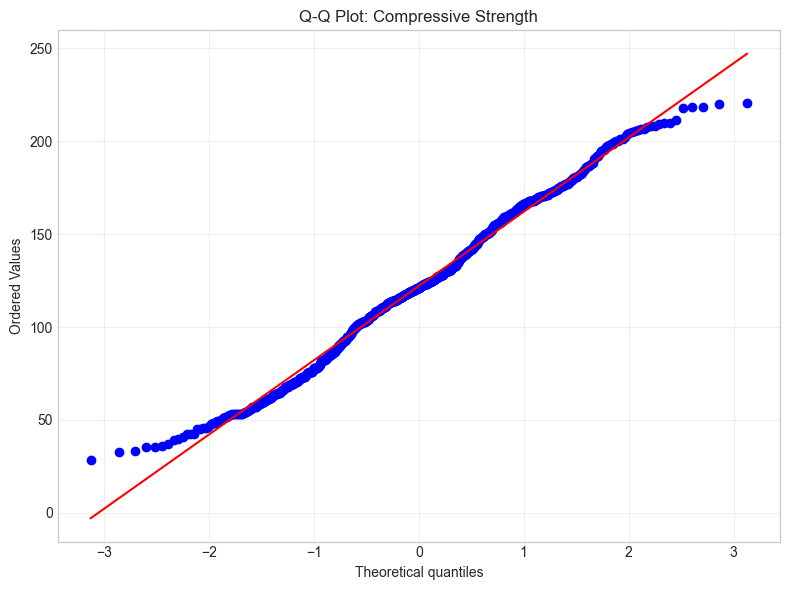

In [16]:
# Q-Q Plot to visually assess normality
target_sample = df[TARGET].sample(5000, random_state=RANDOM_STATE) if len(df) > 5000 else df[TARGET]

fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(target_sample, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Compressive Strength')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'qq_plot_target.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Points closely follow the diagonal reference line, suggesting approximate normality. Minor deviations at the tails are within expected range for this sample size.

In [17]:
# D'Agostino-Pearson test for normality (appropriate for n > 20)
stat, p_value = stats.normaltest(target_sample)

print("D'Agostino-Pearson Test:")
print(f"  Statistic: {stat:.4f}")
print(f"  p-value:   {p_value:.4f}")
print(f"  Result:    {'Normal' if p_value >= 0.05 else 'Not normal'} (α = 0.05)")

D'Agostino-Pearson Test:
  Statistic: 15.2868
  p-value:   0.0005
  Result:    Not normal (α = 0.05)


**Interpretation:** Although the D’Agostino test formally rejects normality, the large sample size (n = 792) may make the test overly sensitive, detecting small deviations that are not practically meaningful.

In [18]:
skew = df[TARGET].skew()
kurt = df[TARGET].kurtosis()

# Evaluate kurtosis - |k| > 1 indicates non-normal tails
print("Shape Statistics:")
print(f"    Skewness: {skew:.3f} —", 
      "Approximately symmetric" if abs(skew) < 0.5 else
      "Moderately skewed" if abs(skew) < 1 else
      "Highly skewed (consider transformation)")

# Evaluate kurtosis - |k| > 1 indicates non-normal tails

print(f"    Kurtosis: {kurt:.3f} —", 
      "Near normal tails" if abs(kurt) < 1 else
      "Heavy tails" if kurt > 1 else
      "Light tails")


Shape Statistics:
    Skewness: 0.034 — Approximately symmetric
    Kurtosis: -0.506 — Near normal tails


**Interpretation:** Skewness (0.03) and kurtosis (-0.51) confirm the distribution is approximately symmetric with near-normal tails.

**Modeling Note:** Together, these metrics confirm the target is close to normal despite the formal test rejection. No transformation will be needed. Residual normality will be reviewed during modeling to confirm this assumption.

### 4.3 Threshold Analysis

In [19]:
# Calculate percentage of samples meeting UHPC threshold
above_threshold = (df[TARGET] >= UHPC_THRESHOLD).sum()
below_threshold = len(df) - above_threshold

print(f"UHPC Threshold Analysis ({UHPC_THRESHOLD} MPa):")
print(f"  Samples >= {UHPC_THRESHOLD} MPa: {above_threshold} ({above_threshold/len(df)*100:.1f}%)")
print(f"  Samples <  {UHPC_THRESHOLD} MPa: {below_threshold} ({below_threshold/len(df)*100:.1f}%)")
print(f"\n  Mean strength above threshold: {df[df[TARGET] >= UHPC_THRESHOLD][TARGET].mean():.2f} MPa")
print(f"  Mean strength below threshold: {df[df[TARGET] < UHPC_THRESHOLD][TARGET].mean():.2f} MPa")

UHPC Threshold Analysis (150 MPa):
  Samples >= 150 MPa: 210 (26.5%)
  Samples <  150 MPa: 582 (73.5%)

  Mean strength above threshold: 172.83 MPa
  Mean strength below threshold: 103.78 MPa


**Interpretation:** Most of the dataset (73.5%) falls below the 150 MPa UHPC threshold, so the model will have fewer high-strength examples to learn from. This imbalance may affect prediction accuracy at the upper range.

**Modeling Note:** Due to imbalance of the target, stratification of train/test splits may be necessary to ensure both sets have representative samples above and below the threshold.

**Section 4 Summary:**
- The target appears approximately normally distributed; no transformation is required for linear modeling.
- Although the formal normality test rejects strict normality, distribution shape remains suitable for modeling.
- Approximately 26.5% of samples exceed the 150 MPa UHPC threshold. Stratified sampling will be used to ensure even test distribution


---
## 5. Analyze Feature Variables

**Methodology:** Feature variables are examined to identify distributional characteristics and relationships with the target:
- Visualize distributions using histograms and box plots to assess shape and detect outliers
- Calculate skewness to flag potential transformation candidates
- Measure feature–target correlations using Pearson coefficients with significance testing
- Assess linearity for the strongest predictors using scatter plots with regression lines
- Use |r| > 0.7 as a threshold for strong feature–target correlation given the engineering context

### 5.1 Feature Distributions (Histograms + KDE)

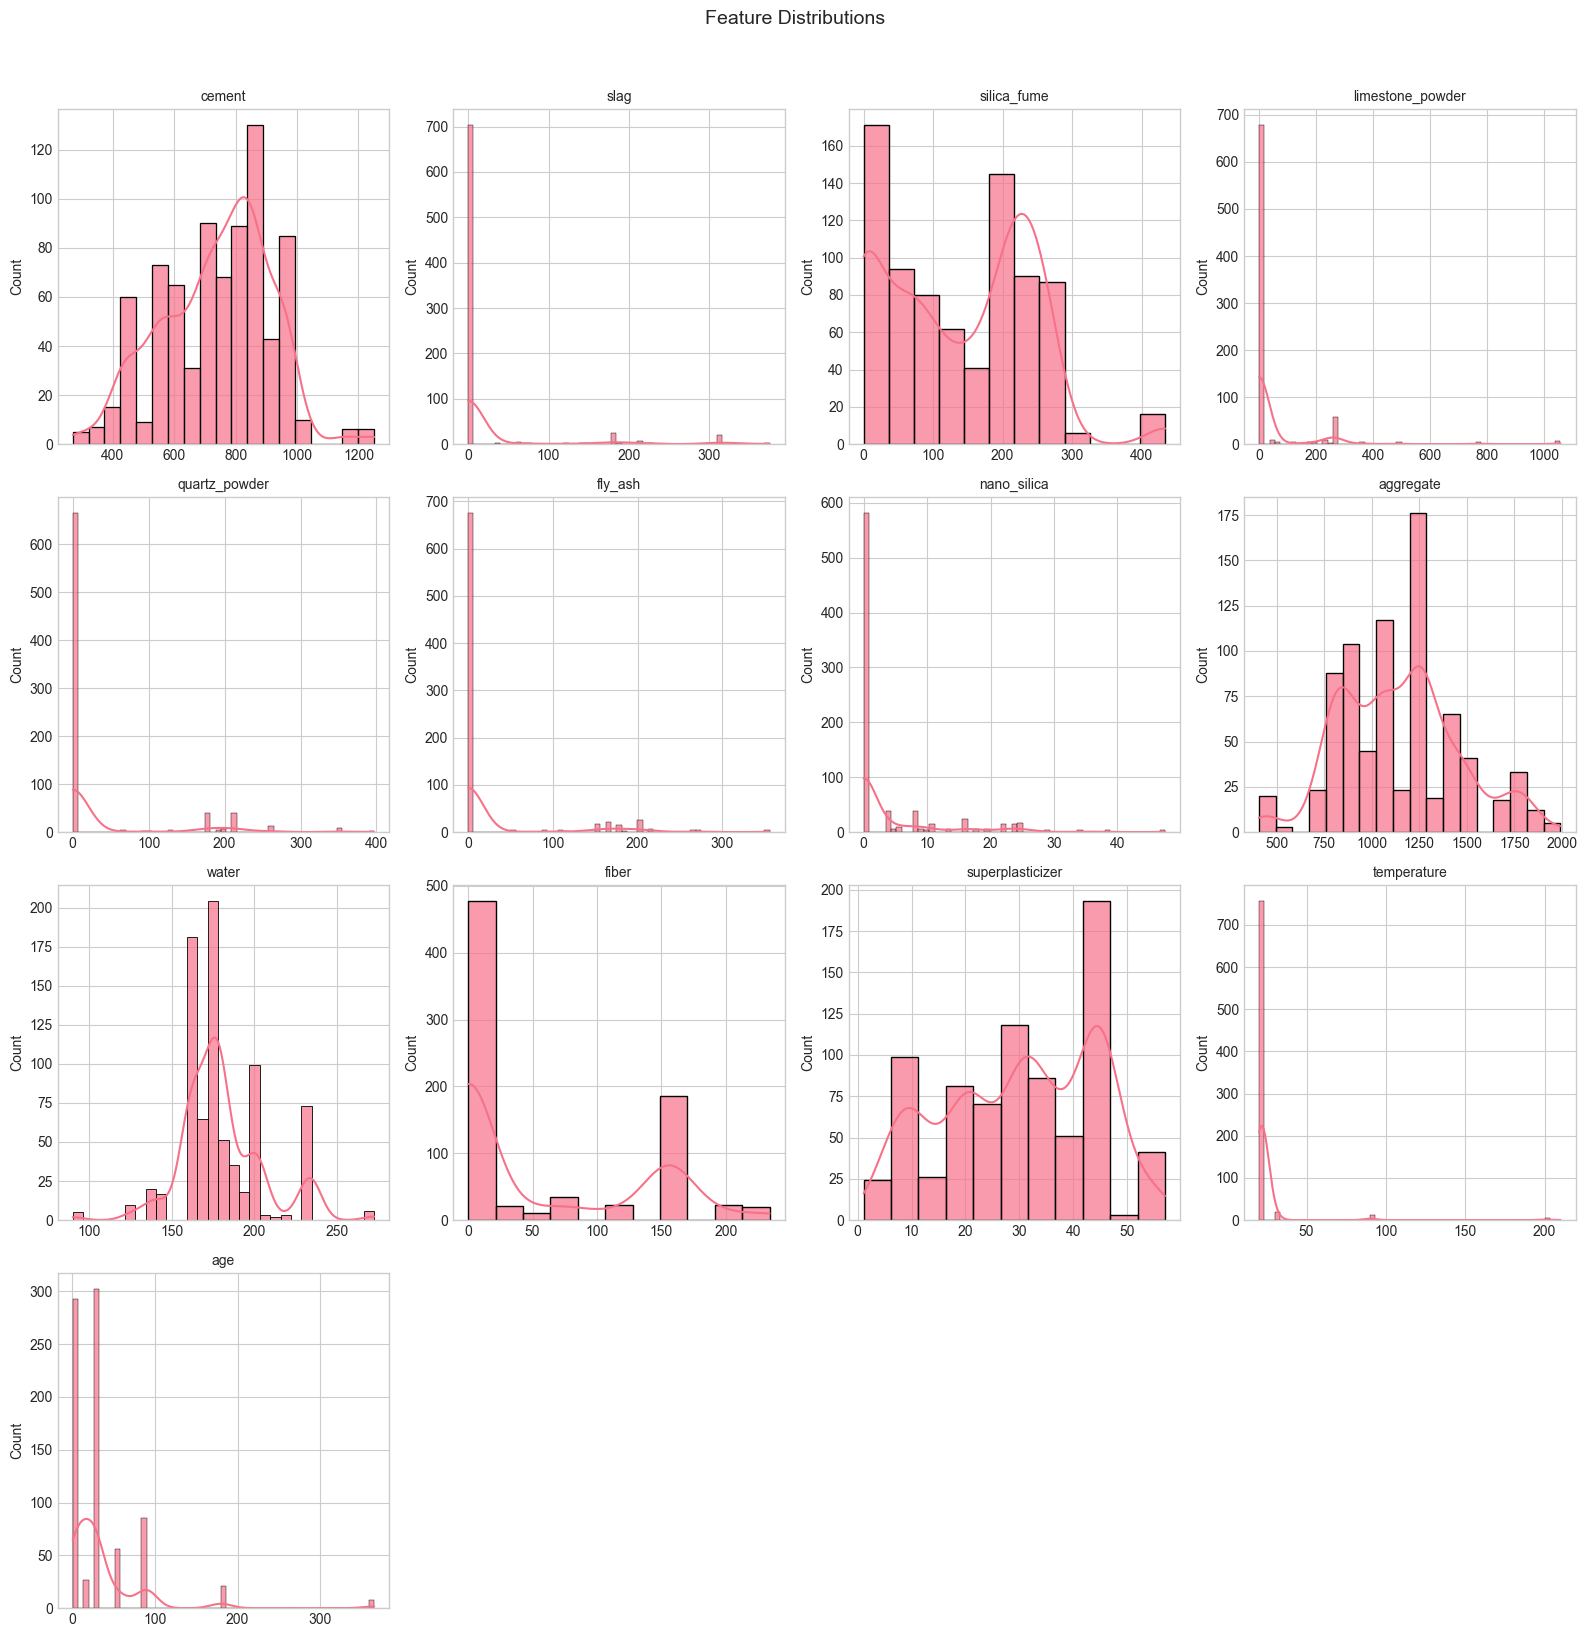

In [20]:
# Create histogram grid showing distribution of all features, distributions reveal skewness, modality, and transformation needs
n_features = len(FEATURES)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.ravel()

for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Feature distributions show two distinct patterns:
- **Optional components** (slag, fly_ash, nano_silica, limestone_powder, quartz_powder, fiber): zero-inflated distributions from mix designs that exclude these ingredients
- **Required components** (cement, water, aggregate, superplasticizer): present in all mixes with continuous distributions

**Modeling Note:** Zero-inflated features may favor tree-based models over linear models. Standard log transforms are not applicable to zero values and log(x+1) may need to be evaluated if transformations are needed.

### 5.2 Outlier Detection (Boxplots)

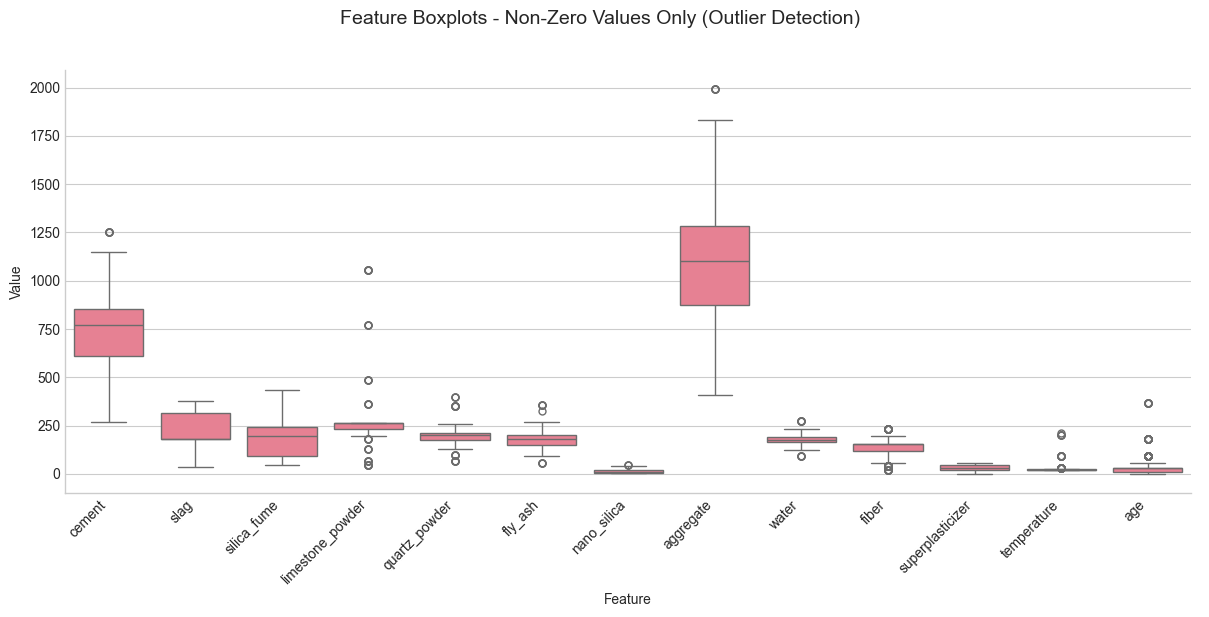

In [21]:
# Create boxplots for non-zero values using melt + seaborn filter to > 10 non-zero records
features_with_data = [col for col in FEATURES if (df[col] > 0).sum() > 10]

# Melt dataframe and filter to non-zero values
df_melted = df[features_with_data].melt(var_name='feature', value_name='value')
df_melted = df_melted[df_melted['value'] > 0]

# Create faceted boxplots (vertical orientation)
g = sns.catplot(
    data=df_melted, 
    x='feature', 
    y='value',
    kind='box',
    height=6,
    aspect=2
)
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels('Feature', 'Value')
g.fig.suptitle('Feature Boxplots - Non-Zero Values Only (Outlier Detection)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Boxplots (non-zero values only) confirm the scale differences seen in histograms and reveal outliers in `temperature` and `age`. Outliers appear to represent valid experimental conditions rather than data errors, so removal is not needed. 

**Modeling Note:** Scale differences reinforce the need for feature scaling during modeling.

### 5.3 Skewness Assessment

In [22]:
# Calculate absolute skewness and kurtosis for all features
skew_df = pd.DataFrame({
    '|Skewness|': df[FEATURES].skew().abs(),
    'Kurtosis': df[FEATURES].kurtosis()
}).sort_values('|Skewness|', ascending=False)

print("Feature Shape Statistics (sorted by |skewness|):")
print(skew_df.round(2))
print(f"\nFeatures with |skew| > 1: {(skew_df['|Skewness|'] > 1).sum()}")

Feature Shape Statistics (sorted by |skewness|):
                  |Skewness|  Kurtosis
temperature             9.04     89.65
limestone_powder        4.70     27.65
age                     3.89     20.54
slag                    3.18      9.19
nano_silica             2.49      6.48
fly_ash                 2.45      5.12
quartz_powder           2.31      4.40
fiber                   0.81     -0.99
water                   0.60      1.71
aggregate               0.27     -0.12
silica_fume             0.25     -0.61
cement                  0.23     -0.16
superplasticizer        0.20     -1.07

Features with |skew| > 1: 7


**Interpretation:** Seven features show high skewness (|skew| > 1), primarily due to zero-inflation, which may limit linear models that assume symmetric inputs.

**Modeling Note:** These are flagged as potential transformation candidates; however, the need for transformation depends on model type. Tree-based models handle skewness naturally and will be evaluated during model development.

### 5.4 Feature-Target Correlations

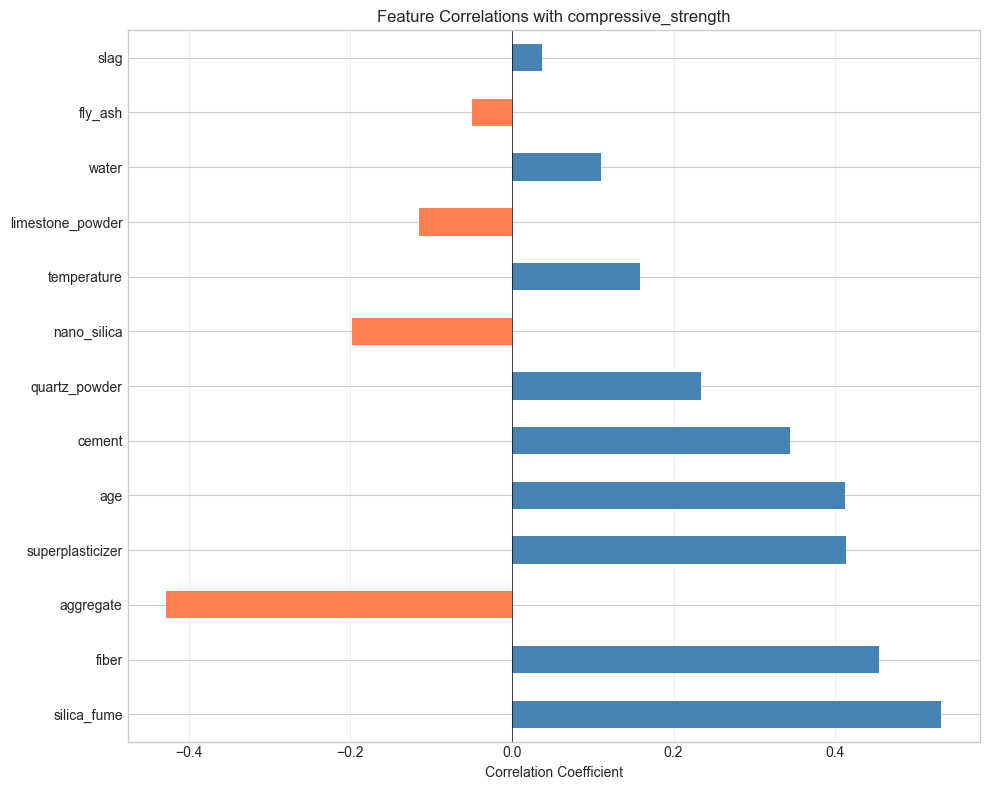

In [23]:
# Calculate Pearson correlations between all features and target
correlations = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

# Create horizontal bar chart of correlations sorted by absolute value
plt.figure(figsize=(10, 8))
colors = np.where(correlations >= 0, 'steelblue', 'coral')
correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation Coefficient')
plt.title(f'Feature Correlations with {TARGET}', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Six features show moderate correlation with compressive strength (|r| 0.3–0.7) and may be the strongest linear predictors. No feature exceeds |r| > 0.7, suggesting compressive strength is not strongly linearly dependent on any single ingredient. The remaining variation may be captured by non-linear relationships or feature interactions.

### 5.5 Statistical Significance Testing

In [24]:
# Calculate p-values for correlations to assess statistical significance
alpha = 0.05

sig_df = pd.DataFrame({
    'Feature': FEATURES,
    'Correlation': [df[col].corr(df[TARGET]) for col in FEATURES],
    'p_value': [stats.pearsonr(df[col], df[TARGET])[1] for col in FEATURES]
})
sig_df['Significant'] = sig_df['p_value'] < alpha
sig_df = sig_df.sort_values('p_value')

print(f"Statistical Significance Testing (α = {alpha}):")
print(sig_df.round(4).to_string(index=False))

print(f"\nSignificant correlations: {sig_df['Significant'].sum()} / {len(FEATURES)}")

Statistical Significance Testing (α = 0.05):
         Feature  Correlation  p_value  Significant
     silica_fume         0.53     0.00         True
           fiber         0.45     0.00         True
       aggregate        -0.43     0.00         True
superplasticizer         0.41     0.00         True
             age         0.41     0.00         True
          cement         0.34     0.00         True
   quartz_powder         0.23     0.00         True
     nano_silica        -0.20     0.00         True
     temperature         0.16     0.00         True
limestone_powder        -0.11     0.00         True
           water         0.11     0.00         True
         fly_ash        -0.05     0.17        False
            slag         0.04     0.29        False

Significant correlations: 11 / 13


**Interpretation:** 11 of 13 features reach statistical significance, though at this sample size even weak correlations can appear significant, so importance should be confirmed during modeling.

 **Modeling Note:** Because statistical significance does not necessarily indicate importance, fly ash and slag will remain in the model rather than being dropped based solely on p-value criteria.

### 5.6 Scatter Plots (Top 5 Correlated Features)

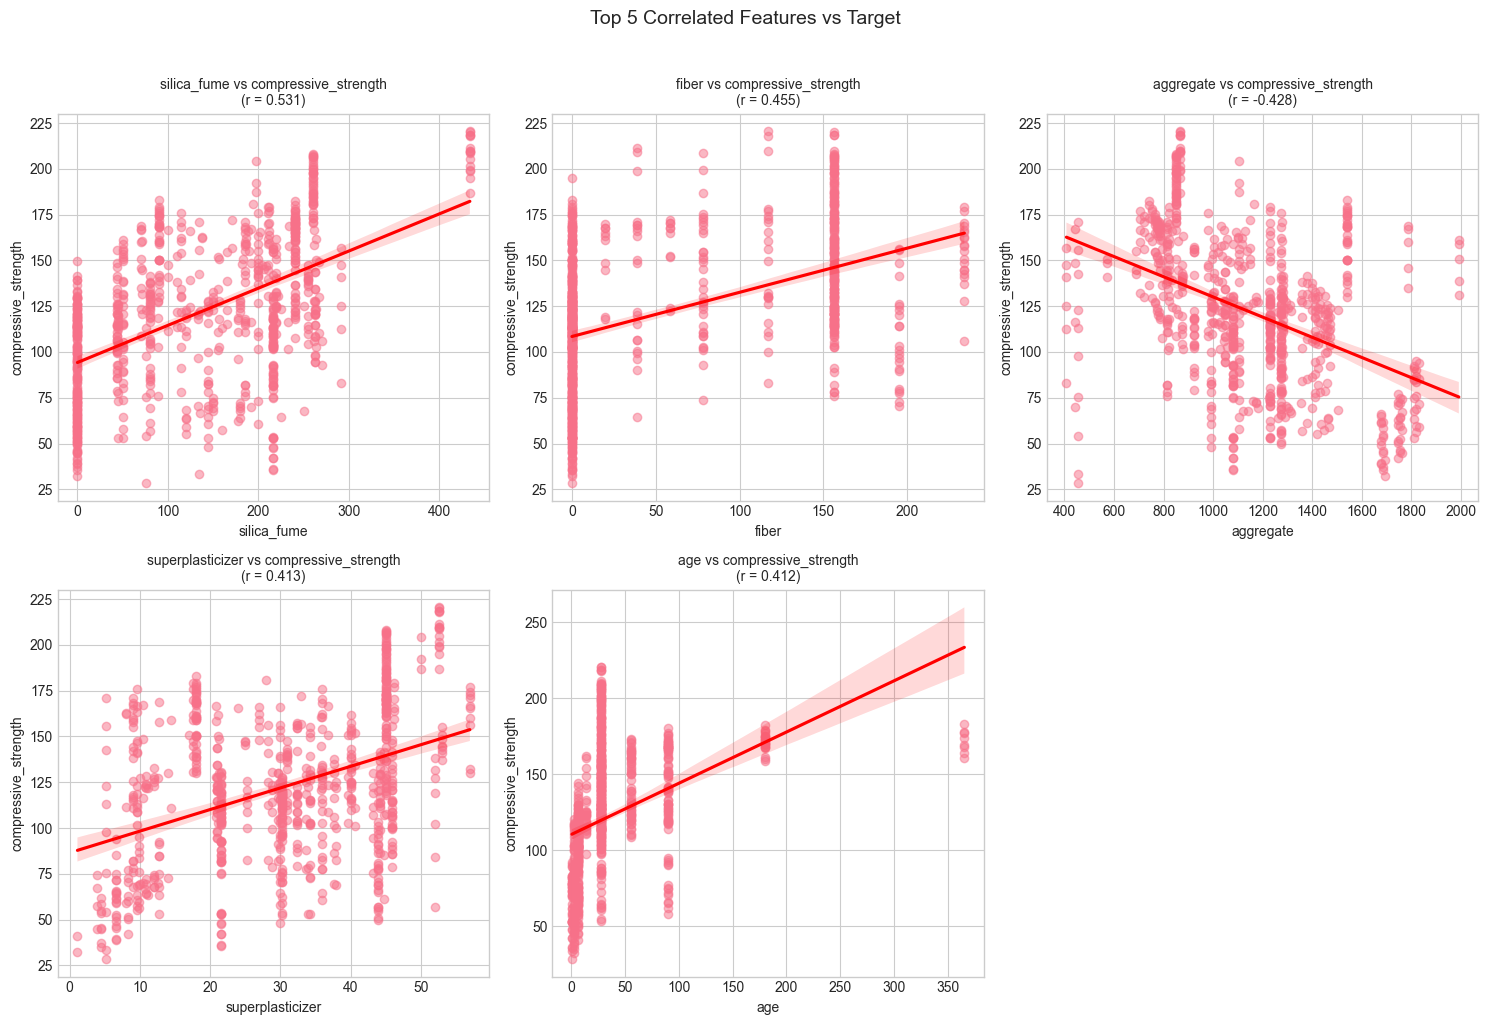

In [25]:
# Create scatter plots with regression lines for top 5 correlated features to reveal linearity, heteroscedasticity, and influential points
top_5 = correlations.head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(top_5):
    sns.regplot(x=df[col], y=df[TARGET], ax=axes[i], scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    axes[i].set_title(f'{col} vs {TARGET}\n(r = {correlations[col]:.3f})', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

axes[5].set_visible(False)

plt.suptitle('Top 5 Correlated Features vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'top5_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**  Scatter plots show directional trends for the top 5 correlated features but without clear linear relationships. Fiber and silica_fume show vertical banding from zero-inflation, and age shows discrete grouping at standard curing intervals.

**Modeling Note:** The absence of clear linear patterns, combined with zero-inflation and some discrete grouping, suggests tree-based models may better capture these relationships than linear models.

**Section 5 Summary:**
- Six features show moderate correlation with strength, led by silica_fume, fiber, and aggregate.
- Several features show high skewness, likely driven by zero-inflated optional mix components.
- Scatter plots did not reveal clear linear relationships, showing wide variance and structural patterns (zero-inflation banding, discrete grouping).
- These characteristics favor tree-based models, which handle skewness and zero-inflation without transformation


---
## 6. Assess Multicollinearity

**Methodology:** 

- Visualize pairwise feature correlations using a heatmap
- Identify highly correlated feature pairs (|r| > 0.7) 
- Calculate Variance Inflation Factors (VIF) 
- Identify possible model selection decisions based on VIF severity

### 6.1 Correlation Heatmap (All Features)

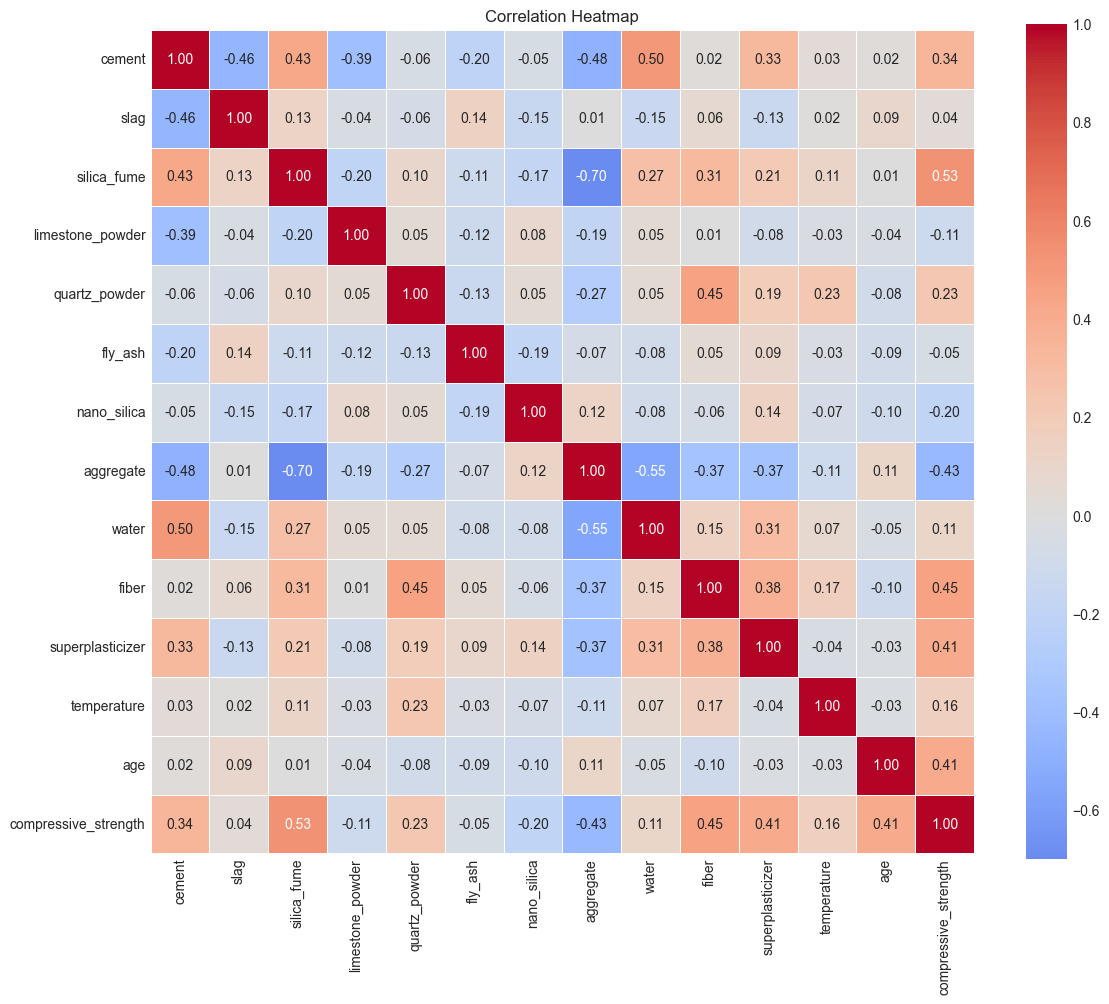

In [26]:
# Create correlation heatmap for all features to reveal multicollinearity patterns that affect linear model stability
plt.figure(figsize=(12, 10))
corr_matrix = df[FEATURES + [TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=12)
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The heatmap reveals moderate correlations among a few ingredients (cement, water, aggregate, silica_fume). The strongest feature-feature correlation (silica_fume–aggregate: r=-0.70) is moderately strong but does not exceed the multicollinearity threshold.

### 6.2 Highly Correlated Feature Pairs

Identify pairs with |r| > 0.7 

In [27]:
# Show all pairwise correlations sorted by absolute value
CORR_THRESHOLD = 0.7

feature_corr = df[FEATURES].corr()

# Extract upper triangle of correlation matrix (exclude diagonal)
corr_pairs = []
for i in range(len(FEATURES)):
    for j in range(i+1, len(FEATURES)):
        corr_pairs.append({
            'Feature_1': FEATURES[i],
            'Feature_2': FEATURES[j],
            'Correlation': feature_corr.iloc[i, j]
        })

pairs_df = pd.DataFrame(corr_pairs)
pairs_df['Abs_Corr'] = pairs_df['Correlation'].abs()
pairs_df = pairs_df.sort_values('Abs_Corr', ascending=False).drop(columns='Abs_Corr')

# Classify correlation strength
pairs_df['Strength'] = pd.cut(
    pairs_df['Correlation'].abs(),
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Weak', 'Moderate', 'Strong']
)

# Show distribution summary
print("Correlation Strength Distribution:")
print(f"  Strong (|r| > 0.7):   {(pairs_df['Strength'] == 'Strong').sum()}")
print(f"  Moderate (0.3-0.7):   {(pairs_df['Strength'] == 'Moderate').sum()}")
print(f"  Weak (|r| < 0.3):     {(pairs_df['Strength'] == 'Weak').sum()}")
print(f"  Total pairs:          {len(pairs_df)}")

# Show top correlations
print(f"\nTop 10 Feature Pair Correlations (sorted by |r|):")
print(pairs_df.head(10).to_string(index=False))

# Flag high correlations
high_corr = pairs_df[pairs_df['Correlation'].abs() > CORR_THRESHOLD]
if len(high_corr) > 0:
    print(f"\n {len(high_corr)} pairs exceed threshold (|r| > {CORR_THRESHOLD})")
else:
    print(f"\n No feature pairs exceed threshold (|r| > {CORR_THRESHOLD})")

Correlation Strength Distribution:
  Strong (|r| > 0.7):   0
  Moderate (0.3-0.7):   14
  Weak (|r| < 0.3):     64
  Total pairs:          78

Top 10 Feature Pair Correlations (sorted by |r|):
    Feature_1        Feature_2  Correlation Strength
  silica_fume        aggregate        -0.70 Moderate
    aggregate            water        -0.55 Moderate
       cement            water         0.50 Moderate
       cement        aggregate        -0.48 Moderate
       cement             slag        -0.46 Moderate
quartz_powder            fiber         0.45 Moderate
       cement      silica_fume         0.43 Moderate
       cement limestone_powder        -0.39 Moderate
        fiber superplasticizer         0.38 Moderate
    aggregate superplasticizer        -0.37 Moderate

 No feature pairs exceed threshold (|r| > 0.7)


**Interpretation:** No feature pairs exceed the |r| > 0.7 threshold individually, though combined effects may still produce multicollinearity as evaluated in the VIF analysis below.

### 6.3 Variance Inflation Factor (VIF)

In [28]:
# Calculate Variance Inflation Factor for each feature using pd.cut for classification
X = df[FEATURES].dropna()

# Calculate VIF for all features
vif_values = [variance_inflation_factor(X.values, i) for i, col in enumerate(FEATURES)]

# Create dataframe and classify severity using pd.cut
vif_df = pd.DataFrame({'Feature': FEATURES, 'VIF': vif_values})
vif_df['Multicollinearity'] = pd.cut(
    vif_df['VIF'],
    bins=[0, 5, 10, float('inf')],
    labels=['OK', 'Moderate', 'Severe']
)
vif_df = vif_df.sort_values('VIF', ascending=False)

print("Variance Inflation Factors:")
print("  Interpretation (Hair et al., 2010): OK (VIF ≤ 5) | Moderate (5-10) | Severe (>10)")
print()
print(vif_df.round(2).to_string(index=False))

# Summary
print(f"\nSummary:")
print(f"  Severe (VIF > 10):  {(vif_df['Multicollinearity'] == 'Severe').sum()}")
print(f"  Moderate (5-10):    {(vif_df['Multicollinearity'] == 'Moderate').sum()}")
print(f"  OK (VIF ≤ 5):       {(vif_df['Multicollinearity'] == 'OK').sum()}")

Variance Inflation Factors:
  Interpretation (Hair et al., 2010): OK (VIF ≤ 5) | Moderate (5-10) | Severe (>10)

         Feature   VIF Multicollinearity
           water 72.71            Severe
          cement 59.12            Severe
       aggregate 13.37            Severe
superplasticizer  8.64          Moderate
     silica_fume  5.88          Moderate
     temperature  3.44                OK
           fiber  2.56                OK
            slag  1.81                OK
limestone_powder  1.75                OK
   quartz_powder  1.66                OK
             age  1.63                OK
     nano_silica  1.44                OK
         fly_ash  1.41                OK

Summary:
  Severe (VIF > 10):  3
  Moderate (5-10):    2
  OK (VIF ≤ 5):       8


**Interpretation:** Three features (water, cement, aggregate) show severe multicollinearity with VIF > 10.

**Modeling Note:** Multicollinearity may cause instability in ordinary least squares regression, suggesting the need to evaluate regularized models (Ridge, LASSO). Tree-based models are unaffected by multicollinearity and can use all features directly.

**Section 6 Summary:**
- Water, cement, and aggregate form a multicollinear cluster, which may impact linear model stability.
- This supports the use of regularized linear models or tree-based models to improve stability.
- An |r| > 0.7 threshold was used to flag strongly related variables; however, VIF was used as the primary diagnostic since multicollinearity can arise from moderate combined correlations

---
## 7. Conclusion

**EDA Results:**

Data characteristics (zero-inflation, distributional skewness, multicollinearity, and absence of clear linear patterns) favor tree-based models. The following models will be evaluated in Notebook 02:

- Baseline: Linear Regression
- Regularized (for multicollinearity): Ridge, LASSO
- Tree-based (for zero-inflation, skewness, and absence of clear linear patterns): Random Forest, XGBoost

**Key Findings:**
- **Data Quality:** Dataset is clean: no missing or out-of-range values; 18 duplicate rows removed (2.2%), leaving 792 records
- **Target Distribution:** Compressive strength is approximately normal (mean: 122 MPa, std: 40 MPa, skewness: 0.03), no transformation required
- **UHPC Threshold Coverage:** 26.5% of samples meet UHPC threshold (≥150 MPa), stratification should be applied
- **Feature-Target Relationships:** Strongest predictors: silica_fume (r=0.53), fiber (r=0.45), aggregate (r=-0.43)
- **Feature-Target Linearity:** Scatter plots did not reveal clear linear relationships; wide variance and structural patterns (zero-inflation banding, discrete grouping) were observed
- **Multicollinearity:** 3 features with severe VIF (>10): water, cement, aggregate indicate need for regularization in linear models


**Limitations:**
- Dataset size (n=792) may limit the model's ability to generalize to additional UHPC formulations
- Fiber and aggregate types unspecified
- Feature-target correlations used Pearson (linear) coefficients; Spearman rank correlation may reveal stronger non-linear associations

**Outputs:**
- `data/processed/uhpc_dataset_cleaned.csv` — Cleaned dataset ready for modeling
- `images/` — Visualizations saved for reporting

**Next Steps:**
Proceed to **02_model_development.ipynb** for model training and comparison.

---
## Appendix A: Data Validation Ranges

**Validation Ranges (Min–Max Valid):**
- **cement:** 200–1500 kg/m³ (typical: 700–1000)
- **slag:** 0–600 kg/m³ (typical: 0–400)
- **silica_fume:** 0–500 kg/m³ (typical: 150–300)
- **limestone_powder:** 0–1200 kg/m³ (typical: 0–300)
- **quartz_powder:** 0–500 kg/m³ (typical: 0–400)
- **fly_ash:** 0–400 kg/m³ (typical: 0–200)
- **nano_silica:** 0–100 kg/m³ (typical: 0–50)
- **aggregate:** 0–2500 kg/m³ (type unspecified)
- **water:** 50–350 kg/m³ (typical: 150–200)
- **fiber:** 0–300 kg/m³ (type unspecified)
- **superplasticizer:** 0–100 kg/m³ (typical: 10–60)
- **temperature:** 0–250 °C (typical: 20–90)
- **age:** 1–1000 days (typical: 1–365)
- **compressive_strength:** 0–350 MPa (typical: 120–250)

**Disclaimer:** Due diligence was done to research valid ranges to apply to the data based on UHPC literature. However, values should be further justified before applying to real-world scenarios.

**Notes:**
- `fiber` and `aggregate` have material types unspecified in the dataset, so only basic range validation is applied.
- Validation ranges are intentionally wider than typical ranges to avoid flagging valid experimental data.

**Validation Range Sources:**
- FHWA-HRT-13-060 (June 2013) — cement, water, compressive_strength ranges
- PMC9228538 (June 2022) — silica_fume, limestone_powder, quartz_powder, superplasticizer ranges
- PMC5455500 (August 2015) — temperature, age ranges
- Springer Pozzolanic Materials (May 2025) — slag, fly_ash ranges
- ScienceDirect Nano-silica (May 2014) — nano_silica ranges

---
## Appendix B: References

Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.

Federal Highway Administration. (2013). *Ultra-High Performance Concrete: A State-of-the-Art Report for the Bridge Community* (FHWA-HRT-13-060).

Federal Highway Administration. (2018). *Properties and Behavior of UHPC-Class Materials* (FHWA-HRT-18-036).

Hair, J. F., Black, W. C., Babin, B. J., & Anderson, R. E. (2010). *Multivariate Data Analysis* (7th ed.). Pearson.

Kashem, A., Karim, R., Malo, S., & Hasan, M. (2023). Ultra-High-Performance Concrete (UHPC). Mendeley Data.